In [11]:
# Imports
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as transforms
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

In [2]:
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, src_path)

In [3]:
from autoencoder import SpatialVAE

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [15]:
data_file = "../data/data_96_bw.npz"
autoencoder_model_file = "../models/spatial_autoencoder.pth"

In [8]:
# load data
data = np.load(data_file)

train_tensor = torch.from_numpy(data["train"].astype(np.float32))
test_tensor = torch.from_numpy(data["test"].astype(np.float32))

train_tensor_dataset = TensorDataset(
    train_tensor, torch.zeros(len(train_tensor), dtype=torch.long)
)
test_tensor_dataset = TensorDataset(
    test_tensor, torch.zeros(len(test_tensor), dtype=torch.long)
)

train_loader = DataLoader(
    train_tensor_dataset, batch_size=64, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    test_tensor_dataset, batch_size=64, shuffle=False, num_workers=2
)

In [17]:
autoencoder = torch.load(autoencoder_model_file, weights_only=False, map_location=torch.device('cpu'))
autoencoder.to(device)
autoencoder.eval()

SpatialVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): SiLU()
    (2): DownBlock(
      (conv): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): SiLU()
      (res): Sequential(
        (0): ResBlock(
          (block): Sequential(
            (0): GroupNorm(8, 64, eps=1e-05, affine=True)
            (1): SiLU()
            (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (3): GroupNorm(8, 64, eps=1e-05, affine=True)
            (4): SiLU()
            (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          )
        )
        (1): ResBlock(
          (block): Sequential(
            (0): GroupNorm(8, 64, eps=1e-05, affine=True)
            (1): SiLU()
            (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

In [28]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 300,
    }
)
 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
 
 
def get_four_images(dataloader) -> torch.Tensor:
    batch = next(iter(dataloader))
    images = batch[0] if isinstance(batch, (list, tuple)) else batch
    return images[:4]
 
 
def plot_reconstructions(model, dataloader, save_path="../vae_reconstructions"):
    model.eval()
    images = get_four_images(dataloader).to(DEVICE)
 
    with torch.no_grad():
        recons, *_ = model(images)
        recons = recons.clamp(0, 1)
 
    orig  = images.cpu().numpy()[:, 0]   # (4, H, W)
    recon = recons.cpu().numpy()[:, 0]
 
    fig, axes = plt.subplots(
        2, 4,
        figsize=(7, 3.8),
        gridspec_kw={"wspace": 0.04, "hspace": 0.06},
    )
 
    row_data   = [orig, recon]
    row_labels = ["Original", "Reconstructed"]
 
    for row, (imgs, label) in enumerate(zip(row_data, row_labels)):
        for col in range(4):
            ax = axes[row][col]
            ax.imshow(imgs[col], cmap="gray", vmin=0, vmax=1,
                      interpolation="lanczos", aspect="equal")
            ax.axis("off")
 
            if col == 0:
                ax.set_ylabel(label, fontsize=8, fontweight="bold",
                              labelpad=5, rotation=90, va="center")
                ax.yaxis.set_visible(True)
                ax.yaxis.set_ticks([])
                ax.yaxis.set_tick_params(length=0)
 
    fig.savefig(f"{save_path}.pdf", bbox_inches="tight", pad_inches=0.05)
    fig.savefig(f"{save_path}.png", bbox_inches="tight", pad_inches=0.05)
    print(f"Saved → {save_path}.pdf / .png")
    plt.show()

Saved → ../vae_reconstructions.pdf / .png


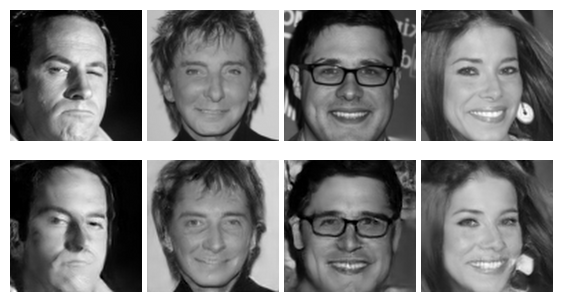

In [34]:
plot_reconstructions(autoencoder, train_loader)